## ML workflow (demo) for a supervised learning landcover classified

- Using the ODC framework
- - this example is for a single class  - agricultural areas.
  - extract ODC data for each labelled area
  - train a decision tree and parameter adjustment
  - predict landcover using trained model on new data
  - evaluate model performance with quant metrics and qual tools

This notebook is mostly based on the ML how to guide, but may expand to use the scalable ML on ODC realworld example notebook

In [1]:
%matplotlib inline

import os
import subprocess as sp
import sys
from io import StringIO

import datacube
import geopandas as gpd
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pydotplus
import rasterio
import shapely
import xarray as xr
from datacube.utils import geometry
from datacube.utils.cog import write_cog
from datacube.utils.geometry import assign_crs
from IPython.display import Image
from odc.io.cgroups import get_cpu_quota
from sklearn import model_selection, tree
from sklearn.metrics import accuracy_score

sys.path.insert(1, ".../Tools/")
import warnings

from dea_tools.bandindices import calculate_indices
from dea_tools.classification import collect_training_data, predict_xr

warnings.filterwarnings("ignore")

In [2]:
dc = datacube.Datacube(app="ML_with_ODC_jenna_practice")

In [3]:
dc_products = dc.list_products()
display_columns = ["name", "description"]

dc_products[dc_products.name.str.contains("ga_ls8cls9c_gm").fillna(False)][
    display_columns
].set_index("name")

,description
name,
ga_ls8cls9c_gm_cyear_3,Geoscience Australia Landsat Nadir BRDF Adjust...


In [4]:
# Functions at top of notebook for easy reference


def custom_function(query):
    dc = datacube.Datacube(app="custom_feature_layers")
    result = dc.load(
        product="ga_ls8cls9c_gm_cyear_3", **query
    )  # This needs to be updated in the original notebook, calling an old product
    return result

In [5]:
path = "../Supplementary_data/Machine_learning_with_ODC/example_training_data.shp"
field = "classnum"  # column in shapefile with class labels
time = "2015"
zonal_stats = "median"  # shoudl also do mean and stdev
resolution = (-30, 30)
output_crs = "EPSG:3577"

# we're auto-detecting the cpu's
ncpus = round(
    get_cpu_quota()
)  # set to >1 to parallelize the collection of training data

print(ncpus)

2


In [6]:
# queries, hardcoded variables etc kept together near top of notebooks
query = {
    "time": time,
    "resolution": resolution,
    "output_crs": output_crs,
    "group_by": "solar_day",
}

### Loading and previewing data

- to speed up the analysis downsample the input data polygons. Can use original polygons later on if I want to do full analysis

In [7]:
input_data = gpd.read_file(path)

input_data1 = input_data.groupby("classnum")["geometry"].sample(
    frac=0.5, random_state=1
)
input_data1 = input_data.loc[input_data1.index]
input_data = input_data1.reset_index(drop=True)

# input_data.explore(column=field, legend=False)
input_data.head()

,classnum,geometry
0,111,"POLYGON ((-1522250.000 -3836850.000, -1522250...."
1,111,"POLYGON ((-1517700.000 -3838750.000, -1517700...."
2,111,"POLYGON ((-1543250.000 -3833475.000, -1543250...."
3,111,"POLYGON ((-1544725.000 -3833325.000, -1544725...."
4,111,"POLYGON ((-1548875.000 -3821475.000, -1548925...."


### Data extraction

https://knowledge.dea.ga.gov.au/notebooks/Tools/gen/dea_tools.classification/#dea_tools.classification.collect_training_data

`feature_func` - accepts `dc.load()` like inputs. The custom func in this notebook returns a single array resulting from a DC load based on the query we defined and the product (which is hard coded in the function in this case)

`zonal_stats` - string input. Default of none will return all pixel values. Supports 'mean', 'median', 'min', 'max'

In [8]:
column_names, model_input = collect_training_data(
    gdf=input_data,
    dc_query=query,
    ncpus=ncpus,
    feature_func=custom_function,
    field=field,
    zonal_stats=zonal_stats,
)

Taking zonal statistic: median


  0%|          | 0/109 [00:00<?, ?it/s]

Percentage of possible fails after run 1 = 0.0 %
Removed 0 rows wth NaNs &/or Infs
Output shape:  (109, 11)


### Preprocessing

There are multiple classes in the training data but we're only interested in one of them (class label 111), so we're going to remove the other ones by setting all other classes to 0

In [9]:
# The class labels will be the first column of the output array called model_input, the corresponding variable names captured in the list column_names
model_input

array([[1.11000000e+02, 2.94000000e+02, 6.38000000e+02, ...,
        6.07205383e+02, 6.10182509e-02, 2.20000000e+01],
       [1.11000000e+02, 2.80000000e+02, 5.80000000e+02, ...,
        4.68321960e+02, 5.47122732e-02, 2.10000000e+01],
       [1.11000000e+02, 5.54500000e+02, 9.03000000e+02, ...,
        1.40475342e+03, 1.39854133e-01, 2.30000000e+01],
       ...,
       [2.15000000e+02, 6.49000000e+02, 9.04500000e+02, ...,
        3.22222107e+02, 3.97802144e-02, 2.40000000e+01],
       [2.15000000e+02, 7.93000000e+02, 1.02000000e+03, ...,
        2.64473267e+02, 2.79410258e-02, 2.50000000e+01],
       [2.15000000e+02, 1.31100000e+03, 1.63500000e+03, ...,
        3.59864502e+02, 2.39863358e-02, 2.10000000e+01]])

In [10]:
# based on above, select first column and replace everything that is not 111 with 0, and replace 111 with 1.
model_input[:, 0] = np.where(model_input[:, 0] == 111, 1, 0)

In [11]:
model_train, model_test = model_selection.train_test_split(
    model_input, stratify=model_input[:, 0], train_size=0.8, random_state=0
)

print(f"Train shape: {model_train.shape}")
print(f"Test shape: {model_test.shape}")

Train shape: (87, 11)
Test shape: (22, 11)


## Model preparation

In [12]:
# select variables we want for training model
# To use a custom subset of the satellite bands loaded above to train our data,
# you can replace column_names[1:] with a list of selected band names (e.g. ['red', 'green', 'blue'])

model_variables = column_names[1:]

print(model_variables)

['nbart_blue', 'nbart_green', 'nbart_red', 'nbart_nir', 'nbart_swir_1', 'nbart_swir_2', 'sdev', 'edev', 'bcdev', 'count']


In [13]:
model_col_indices = [column_names.index(var_name) for var_name in model_variables]

print(model_col_indices)

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


In [14]:
# initialise the model

model = tree.DecisionTreeClassifier(max_depth=10)

## Train model

model is fitted/ trained with the prepared TRAINING data. The decision tree creates a generalised representation of reality based on the training data, and this is then used to predict the classes for new data.


In [15]:
model.fit(model_train[:, model_col_indices], model_train[:, 0])

DecisionTreeClassifier(max_depth=10)

## Analyse results

the classifier lets us look at feature importance for each of the input variables (Bands?). Featuer importance = how much that feature contributed in predicting the landcover class.When summed up all variables should =1.0.

Text(0.5, 0, 'Variable')

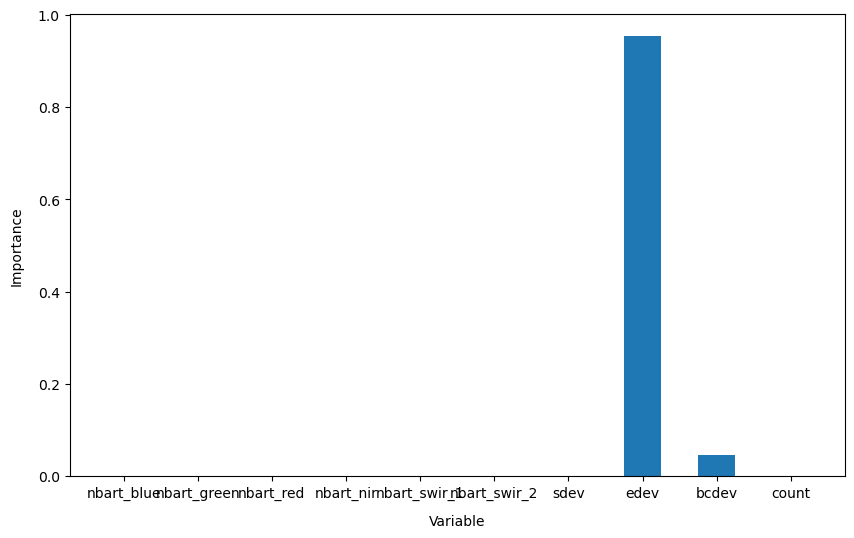

In [16]:
plt.figure(figsize=(10, 6))
plt.bar(x=model_variables, height=model.feature_importances_, width=0.5)

plt.gca().set_ylabel("Importance", labelpad=10)
plt.gca().set_xlabel("Variable", labelpad=10)

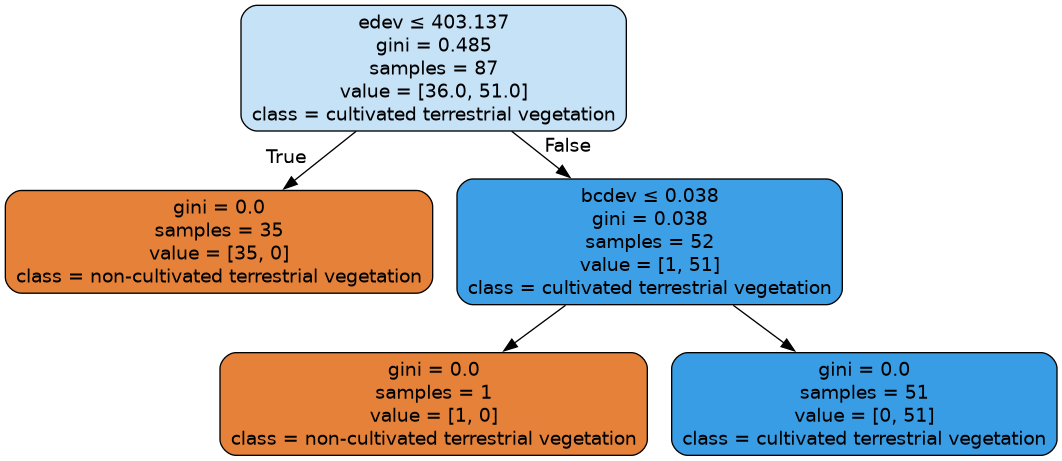

In [17]:
class_names = {
    1: "cultivated terrestrial vegetation",
    0: "non-cultivated terrestrial vegetation",
}

class_codes = np.unique(model_train[:, 0])
class_names_in_model = [class_names[k] for k in class_codes]

# plot decision tree to understand what is happening
dot_data = StringIO()

tree.export_graphviz(
    model,
    out_file=dot_data,
    feature_names=model_variables,
    class_names=class_names_in_model,
    filled=True,
    rounded=True,
    special_characters=True,
)

graph = pydotplus.graph_from_dot_data(dot_data.getvalue())

Image(graph.create_png())

The gini value represents the decrease in node impurity. 

This can also be understood as how heterogeneous the labels are (small values indicating better results). This metric is used by the decision tree to determine how to split the data into smaller groups.

In [18]:
predictions = model.predict(model_test[:, model_col_indices])
accuracy_score(predictions, model_test[:, 0])

# an accuracy of 1 means the model was able to correctly predict 100% of the classes in the Test data
# This seems unlikely?

0.9545454545454546

## Prediction

With the now-trained model we are going to load new data and use the `predict_xr` function to predic land cover classes.

It is advisable to classify data from the same product that the data was originally trained on, even though you could technically use the model to classify data using other DEA products.

In [19]:
# prediction
# get the extent of the shapefile
xmin, ymin, xmax, ymax = input_data.unary_union.bounds

query = {
    "time": time,
    "x": (xmin, xmax),
    "y": (ymin, ymax),
    "crs": "EPSG:3577",
    "resolution": resolution,
}

# use the custom function from the top of the notebook with this new query
input_data = custom_function(query)

In [20]:
predicted = predict_xr(model, input_data, clean=True)  # what does the clean flag do?

predicting...


Text(0.5, 1.0, 'RGB image')

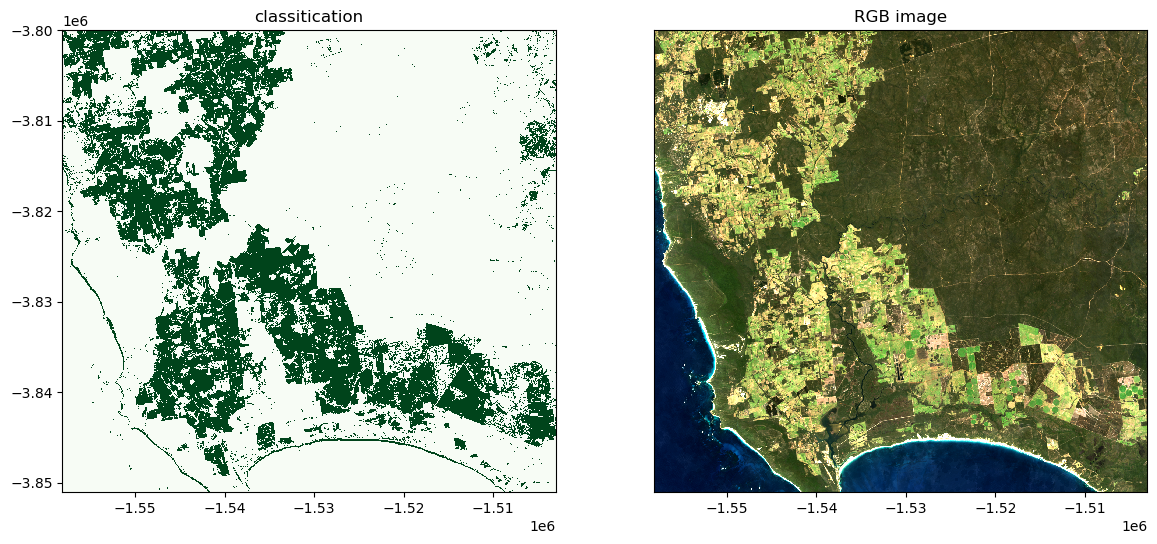

In [21]:
# QUALITATIVELY assess the classification performance by plotting the results next to an image

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

predicted.Predictions.plot(
    ax=axes[0], cmap="Greens", add_labels=False, add_colorbar=False
)

# plot the RGB image
(
    input_data[["nbart_red", "nbart_green", "nbart_blue"]]
    .squeeze("time")
    .to_array()
    .plot.imshow(ax=axes[1], robust=True, add_labels=False)
)  # update in original notebook

# remove axis on right plot
axes[1].get_yaxis().set_visible(False)

# titles
axes[0].set_title("classitication")
axes[1].set_title("RGB image")

# part 2: in depth ml notebooks
There is a series of indepth ML notebooks as well. This section follows them. It should be similar, just more in depth to part 1.

In [22]:
path = "../Real_world_examples/Scalable_machine_learning/data/crop_training_WA.geojson"
field = "class"

In [23]:
input_data = gpd.read_file(path)

# input_data.head()
#input_data.explore(column=field)

## extract training data

`collect_training_data` will take the geojson class labels and extract training data from the datacube over the locations specified by the geojson geometries.

It also pre-processes the training data a bit by stacking the arrays into a "useful format"(?) and removing and `inf` or `NaN` values.

You can set `zonal_stats` within the `collect_training_data` function. Dfault is none (all values returned) or you can specify `mean`, `median`, `max`, `min`.

Same as above, set up a datacube query to use for getting the data over the target areas.


In [24]:
# This is a more complex versio of the function at the top of the notebook

def feature_layers(query):
    dc = datacube.Datacube(app="custom_feature_layers")
    
    ds = dc.load(product='ga_ls8cls9c_gm_cyear_3',
                **query)
    da = calculate_indices(ds,
                          index=["NDVI", "LAI", "MNDWI"],
                          frop=False,
                          collection='ga_ls_3')

    fc = dc.load(product='ga_ls_fc_pc_cyear_3',
                measurements=['pv_pc_10', 'pv_pc_50', 'pv_pc_90'],
                like=ds.geobox,
                time=query.get('time'),
                dask_chunks=query.get('dask_chunks'))

    result = xr.merge([da, fc], compat='override')

    return result

In [25]:
zonal_stats = None

time = "2014"
resolution = (-30, 30)
output_crs = "EPSG:3577"

In [26]:
# inputs for the feature_layers function
query = {"time": time, 
         "resolution": resolution, 
         "output_crs": output_crs}

# product = "ga_ls8cls9c_gm_cyear_3"

# second_product = "ga_ls_fc_pc_cyear_3"
# second_product_measurements = ["pv_pc_10", "pv_pc_50", "pv_pc_90"]

# indices = ["NDVI", "LAI", "MNDWI"]
# collection = "ga_ls_3"

In [27]:
%%time

column_names, model_input = collect_training_data(
    gdf=input_data,
    dc_query=query,
    ncpus=ncpus, #from earlier in notebook
    return_coords=False,
    field=field,
    zonal_stats=zonal_stats,
    feature_func=feature_layers #out function
)

  0%|          | 0/430 [00:00<?, ?it/s]

KeyboardInterrupt: 